In [1]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import minimize
import matplotlib.pyplot as plt


In [2]:
class DCMotor:
    def __init__(self, J=0.01, b=0.1, K=0.01, R=1.0, L=0.5):
        """
        DC Motor Model
        Parameters:
            J: Moment of inertia
            b: Viscous damping coefficient
            K: Motor constant (torque constant and back EMF constant)
            R: Armature resistance
            L: Armature inductance
        State variables:
            x[0]: θ (angle)
            x[1]: ω (angular velocity)
            x[2]: i (current)
        """
        self.J = J
        self.b = b
        self.K = K
        self.R = R
        self.L = L

    def dynamics(self, state, t, v):
        theta, omega, i = state
        
        # Motor dynamics equations
        dtheta = omega
        domega = (self.K * i - self.b * omega) / self.J
        di = (-self.R * i - self.K * omega + v) / self.L
        
        return [dtheta, domega, di]

class CascadedPIDController:
    def __init__(self, kp_pos, ki_pos, kd_pos, kp_vel, ki_vel, kd_vel):
        # Pos loop
        self.kp_pos = kp_pos
        self.ki_pos = ki_pos
        self.kd_pos = kd_pos
        
        # Vel loop
        self.kp_vel = kp_vel
        self.ki_vel = ki_vel
        self.kd_vel = kd_vel
        
        self.reset()
    
    def reset(self):
        # Pos loop
        self.pos_integral = 0
        self.pos_prev_error = 0
        
        # Vel loop
        self.vel_integral = 0
        self.vel_prev_error = 0
    
    def control(self, pos_ref, pos, vel, dt):
        # Pos loop control
        pos_error = pos_ref - pos
        self.pos_integral += pos_error * dt
        pos_derivative = (pos_error - self.pos_prev_error) / dt
        self.pos_prev_error = pos_error
        
        # Pos loop output as the ref input for the vel loop
        vel_ref = (self.kp_pos * pos_error + 
                  self.ki_pos * self.pos_integral + 
                  self.kd_pos * pos_derivative)
        
        # Vel loop control
        vel_error = vel_ref - vel
        self.vel_integral += vel_error * dt
        vel_derivative = (vel_error - self.vel_prev_error) / dt
        self.vel_prev_error = vel_error
        
        # Vel loop output as the voltage input
        v = (self.kp_vel * vel_error + 
             self.ki_vel * self.vel_integral + 
             self.kd_vel * vel_derivative)
        
        return np.clip(v, -24, 24)  # Limit the voltage to the range ±24V


In [3]:
def simulate_system(params):
    kp_pos, ki_pos, kd_pos, kp_vel, ki_vel, kd_vel = params
    
    motor = DCMotor()
    controller = CascadedPIDController(kp_pos, ki_pos, kd_pos, 
                                     kp_vel, ki_vel, kd_vel)
    
    # Sim params
    t = np.linspace(0, 5, 1000)  # 5s, 1000 sample points
    dt = t[1] - t[0]
    pos_ref = 1.0  # Target position of 1 rad
    
    # Initial state [theta, omega, i]
    x0 = [0, 0, 0]
    
    pos_history = []
    vel_history = []
    v_history = []
    
    # Simulate
    x = x0
    for i in range(len(t)):
        v = controller.control(pos_ref, x[0], x[1], dt)
        x = odeint(motor.dynamics, x, [t[i], t[i] + dt], args=(v,))[-1]

        pos_history.append(x[0])
        vel_history.append(x[1])
        v_history.append(v)
    
    return t, np.array(pos_history), np.array(vel_history), np.array(v_history)

def objective(params):
    t, pos, vel, v = simulate_system(params)
    
    pos_ref = 1.0
    pos_error = pos_ref - pos
    
    # Compute performance metrics
    pos_ise = np.sum(pos_error**2)  # Integral of squared position error
    vel_smoothness = np.sum(np.diff(vel)**2)  # Smoothness of velocity
    control_effort = np.sum(v**2)  # Control effort
    
    # Steady-state error (using the average error over the last 0.5 seconds)
    steady_state_error = np.abs(np.mean(pos_error[-100:]))
    
    # Overshoot
    overshoot = np.max(np.maximum(pos - pos_ref, 0))
    
    # Combined objective function
    return (2.0 * pos_ise + 
            500.0 * steady_state_error +  # Emphasize steady-state error
            10.0 * overshoot + 
            0.01 * vel_smoothness +  # Smooth velocity response
            0.001 * control_effort)  # Control energy


Optimal PID parameters:
Position loop:
Kp = 6.822
Ki = 0.000
Kd = 0.000

Velocity loop:
Kp = 7.407
Ki = 0.000
Kd = 1.978

System performance metrics:
Steady-state error = 0.000000
Overshoot = 1.71%
2% settling time = 1.41 seconds


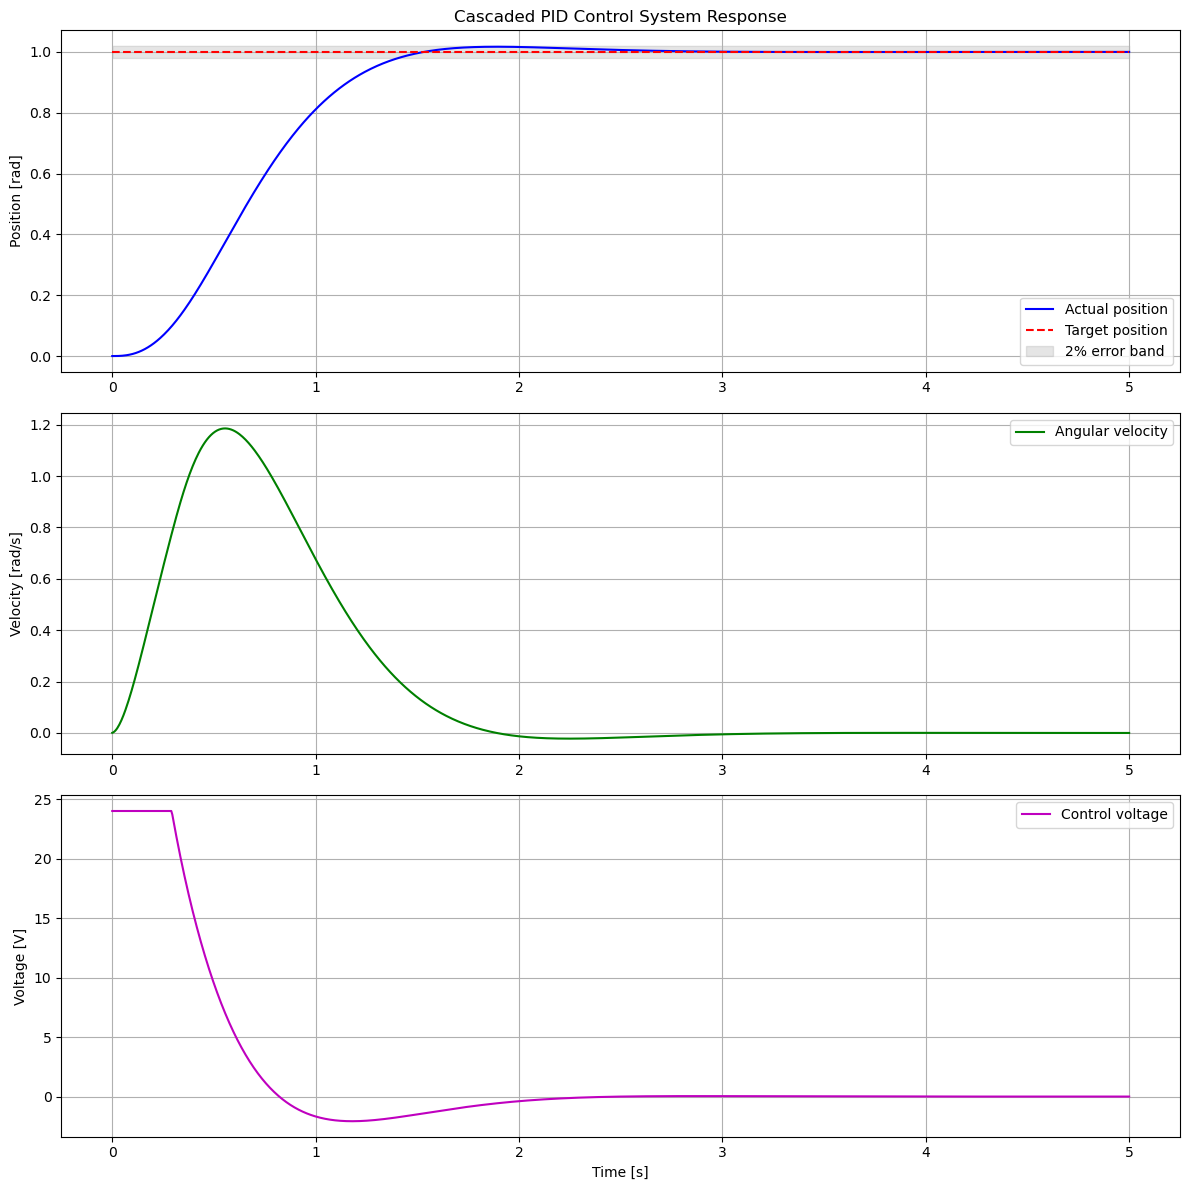

In [4]:
# Initial params and bounds
initial_guess = [5.0, 2.0, 1.0,  # Pos loop PID
                2.0, 1.0, 0.1]  # Vel loop PID
bounds = [(0.1, 20.0), (0.0, 10.0), (0.0, 10.0),  # Pos loop PID
         (0.1, 20.0), (0.0, 10.0), (0.0, 10.0)]   # Vel loop PID

# Optimization
result = minimize(
    objective,
    initial_guess,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100}
)

# Optimal params
best_params = result.x
print("Optimal PID params:")
print("Pos loop:")
print(f"Kp = {best_params[0]:.3f}")
print(f"Ki = {best_params[1]:.3f}")
print(f"Kd = {best_params[2]:.3f}")
print("\nVel loop:")
print(f"Kp = {best_params[3]:.3f}")
print(f"Ki = {best_params[4]:.3f}")
print(f"Kd = {best_params[5]:.3f}")

# Simulate using the optimal params
t, pos, vel, v = simulate_system(best_params)

# Calculate performance metrics
pos_ref = 1.0
error = pos_ref - pos
steady_state_err = np.abs(np.mean(error[-100:]))
overshoot = np.max(np.maximum(pos - pos_ref, 0)) * 100  # Convert to percentage
settling_time = None
settled_threshold = 0.02

# Calculate settling time
for i in range(len(t)):
    if abs(pos[i] - pos_ref) <= settled_threshold * pos_ref:
        if all(abs(pos[j] - pos_ref) <= settled_threshold * pos_ref 
               for j in range(i, min(i + 100, len(pos)))):
            settling_time = t[i]
            break

print(f"\nSystem performance metrics:")
print(f"Steady-state err = {steady_state_err:.6f}")
print(f"Overshoot = {overshoot:.2f}%")
if settling_time:
    print(f"2% settling time = {settling_time:.2f} seconds")
else:
    print("The system did not reach steady state within sim time")

# Plot results
plt.figure(figsize=(12, 12))

# Position response
plt.subplot(3, 1, 1)
plt.plot(t, pos, 'b-', label='Actual pos')
plt.plot(t, np.ones_like(t), 'r--', label='Target pos')
plt.fill_between(t, 
                np.ones_like(t) * (1 + 0.02),
                np.ones_like(t) * (1 - 0.02),
                color='gray', alpha=0.2, label='2% error band')
plt.grid(True)
plt.legend()
plt.ylabel('Pos [rad]')
plt.title('Cascaded PID Control System Response')

# Velocity response
plt.subplot(3, 1, 2)
plt.plot(t, vel, 'g-', label='Ang vel')
plt.grid(True)
plt.legend()
plt.ylabel('Velocity [rad/s]')

# Control input
plt.subplot(3, 1, 3)
plt.plot(t, v, 'm-', label='Ctrl volt')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Volt [V]')

plt.tight_layout()
plt.show()
